# Temas Tratados en el Trabajo Práctico 8

* Aprendizaje estadístico.

* Evolución de la verosimilitud de una hipótesis en función de observaciones.

* Aprendizaje no supervisado. Algoritmo K-means.

* Aprendizaje supervisado. Algoritmo Knn.

* Aprendizaje por refuerzo. Algoritmo Q-Learning.

## Ejercicios Teóricos

1. Un fabricante de tornillos vende cajas que contienen 1000 tornillos de cabeza redonda con tres tipos de recubrimiento electrolítico (cincado, cobre y níquel). Cada caja se rellena
con diferentes proporciones que pueden variar de la siguiente manera:

&emsp;&emsp;a: Todos los tornillos están recubiertos de níquel. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;b: El 70% de los tornillos están recubiertos de níquel, el 20% de cobre, el resto está cincado. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;c: El 50% de los tornillos están recubiertos de níquel, el 25% de cobre y el resto está cincado. 50 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;d: El 20 % de los tornillos están recubiertos de níquel, el 50% de cobre y el resto está cincado. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;e: Todos los tornillos están recubiertos de cobre. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;1.1 ¿Cuál es la distribución a priori sobre las hipótesis?

P(h_a) = 15/100 = 0,15
P(h_b) = 15/100 = 0,15
P(h_c) = 50/100 = 0,50
P(h_d) = 10/100 = 0,10
P(h_e) = 10/100 = 0,10

&emsp;Considerando que los 10 primeros tornillos que se extraen de una caja de muestra son de cobre:

&emsp;&emsp;1.2 Calcule la probabilidad de cada hipótesis dado que los 10 primeros tornillos fueron de cobre.

Aplicando teorema de rayes: P(h_i | d) = α · P(d | h_i) · P(h_i) y suponiendo que son eventos independientes

Vemos sus probabilidades en cada caja

P(d | h_a) = 0^10    = 0
P(d | h_b) = 0,20^10 = 1,024 · 10⁻⁷
P(d | h_c) = 0,25^10 = 9,537 · 10⁻⁷
P(d | h_d) = 0,50^10 = 9,766 · 10⁻⁴
P(d | h_e) = 1,00^10 = 1

producto verosimilitud

h_a: 0,15 · 0            = 0
h_b: 0,15 · 1,024·10⁻⁷   = 1,536 · 10⁻⁸
h_c: 0,50 · 9,537·10⁻⁷   = 4,768 · 10⁻⁷
h_d: 0,10 · 9,766·10⁻⁴   = 9,766 · 10⁻⁵
h_e: 0,10 · 1            = 0,1




&emsp;&emsp;1.3 Grafique la evolución de la verosimilitud de cada hipótesis en función del número de tornillos extraídos de la caja.

&emsp;&emsp;1.4 Para cada hipótesis, ¿cuál es la probabilidad de que el cuarto tornillo extraído sea de cobre?

2. ¿Qué diferencia principal existe entre un algoritmo supervisado y un algoritmo no supervisado?

## Ejercicios de implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

3. Genere un conjunto de 23 puntos que contengan coordenadas *xy* aleatorias con valores contenidos en el intervalo [0, 5] y grafique los puntos obtenidos en un gráfico.

&emsp;&emsp;3.1 Implemente un algoritmo K-means que clasifique 20 de los puntos en 2 grupos y grafique el resultado asignando un color a cada uno.


&emsp;&emsp;3.2 Tome los tres puntos restantes y clasifíquelos en los grupos obtenidos anteriormente usando el algoritmo Knn. Utilice distintos valores de K y anote lo que observa con esta elección.

4. La imagen mostrada abajo muestra una red de salas y cómo se comunican entre ellas. Implemente un algoritmo Q-Learning con un factor despreciativo $γ = 0.9$. La matriz de recompensas debe asignar un valor de 0 a cada camino accesible y un valor de 100 a caminos que lleven a la sala del tesoro.

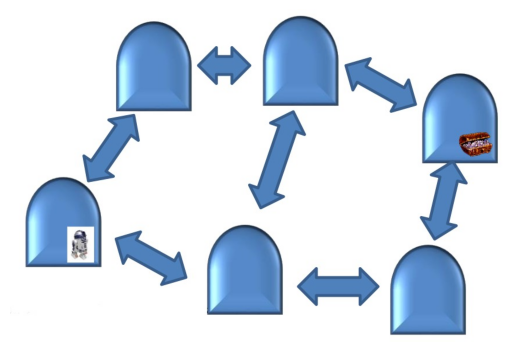

In [1]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1dkDruEIPa7f-BAmjI47TZl3bxaqYf6a9"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

&emsp;&emsp;4.1 Dibuje un diagrama con la asignación de recompensas correspondiente a cada estado.
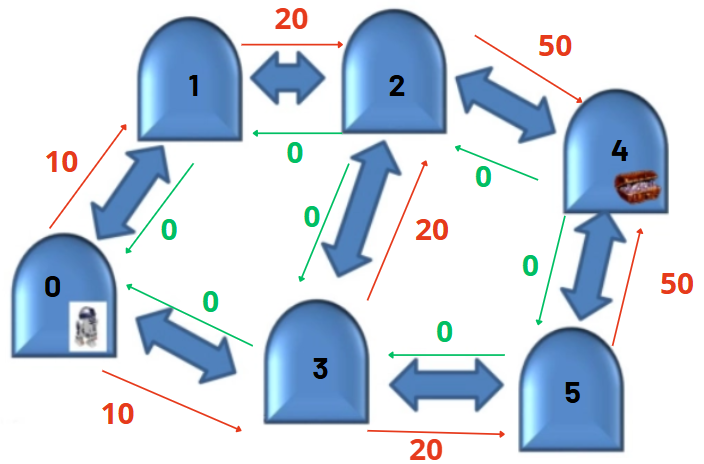
&emsp;&emsp;4.2 Diseñe y muestre la matriz de recompensas.

&emsp;&emsp;4.3 Obtenga la matriz Q óptima, normalícela respecto al valor máximo encontrado y grafique la política obtenida en el diagrama mostrado inicialmente.

=== 4.1 / 4.2  Estados y acciones permitidas por estado ===
S = [0, 1, 2, 3, 4, 5]
  s=0: A(s)=[1, 3]  R(s,.)=[10, 10]
  s=1: A(s)=[0, 2]  R(s,.)=[0, 20]
  s=2: A(s)=[1, 3, 4]  R(s,.)=[0, 0, 50]
  s=3: A(s)=[0, 2, 5]  R(s,.)=[0, 20, 20]
  s=4: A(s)=[2, 5]  R(s,.)=[0, 0]
  s=5: A(s)=[3, 4]  R(s,.)=[0, 50]

=== 4.3  Convergencia ===
Criterio ΔQ < 0.0001: 126 iteraciones (ΔQ final = 9.534e-05)
Refinado a ΔQ < 1e-13: 328 iteraciones (ΔQ final = 8.527e-14)
max|Q(1e-4) - Q(1e-13)| = 4.516e-04
Check analítico  Q(2,4) = 50/(1-γ²) = 263.157895  | numérico = 263.157895

Q* convergida (– = transición no permitida, R = -1):
               a=0         a=1         a=2         a=3         a=4         a=5
  s=0            –  241.157895           –  241.157895           –           –
  s=1   217.042105           –  256.842105           –           –           –
  s=2            –  231.157895           –  231.157895  263.157895           –
  s=3   217.042105           –  256.842105           –          

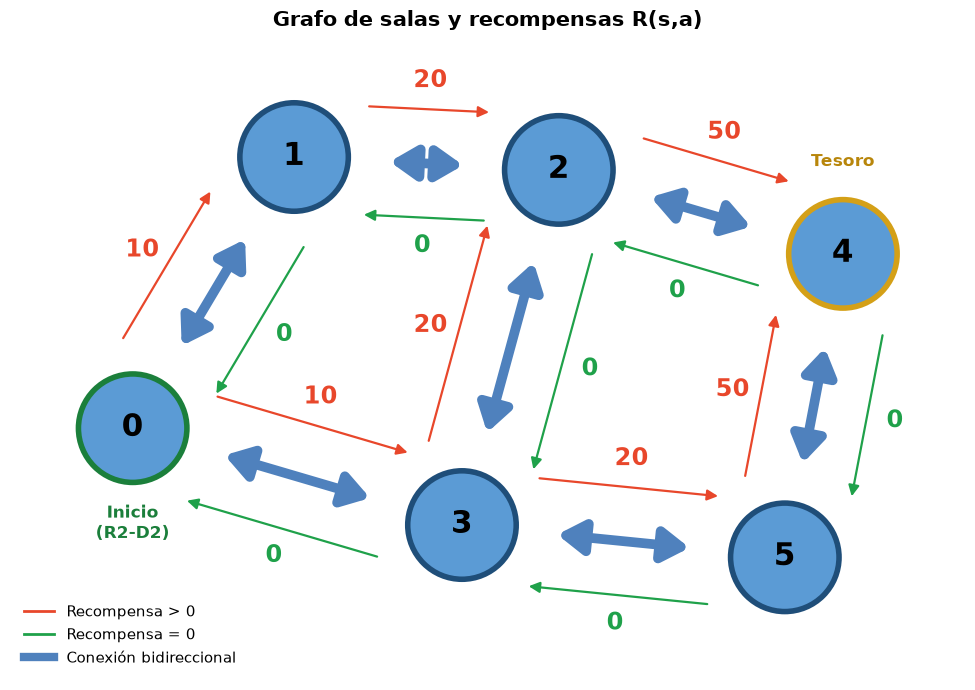

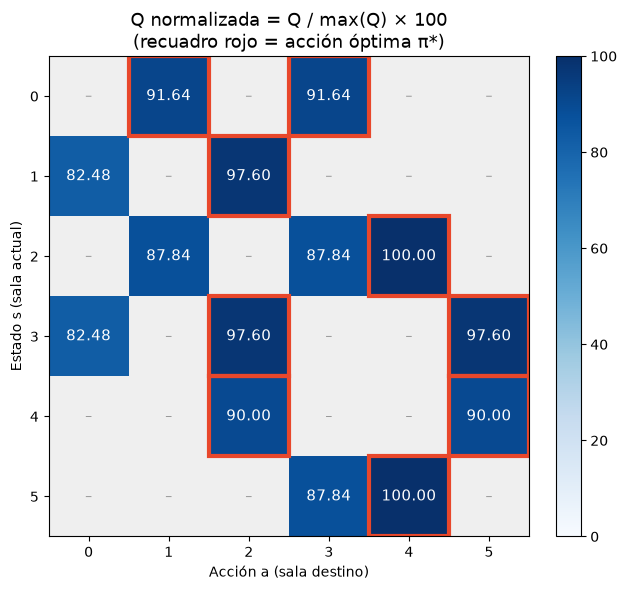

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle, Rectangle
from matplotlib.lines import Line2D

# =============================================================================
# 4.1 y 4.2  MODELO DE RECOMPENSAS
# =============================================================================
# Estados S = {0,...,5} (salas). Acción a = "ir a la sala a" (a ∈ S).
# R[s, a] = recompensa de pasar de s a a  |  -1 => transición NO permitida.
# La matriz se transcribe de los pesos dirigidos del grafo:
#   rojo (hacia adelante/tesoro) : 0→1=10, 0→3=10, 1→2=20, 3→2=20, 3→5=20,
#                                  2→4=50, 5→4=50
#   verde (retroceso / lateral)  : 1→0=0, 2→1=0, 2→3=0, 3→0=0, 4→2=0,
#                                  4→5=0, 5→3=0
N = 6
GAMMA = 0.9
EPS = 1e-4          # criterio de convergencia  ΔQ < 1e-4
META = 4            # sala del tesoro
INICIO = 0          # sala inicial (R2-D2)

R = np.array([
    [-1, 10, -1, 10, -1, -1],   # sala 0 -> {1, 3}
    [ 0, -1, 20, -1, -1, -1],   # sala 1 -> {0, 2}
    [-1,  0, -1,  0, 50, -1],   # sala 2 -> {1, 3, 4}
    [ 0, -1, 20, -1, -1, 20],   # sala 3 -> {0, 2, 5}
    [-1, -1,  0, -1, -1,  0],   # sala 4 -> {2, 5}
    [-1, -1, -1,  0, 50, -1],   # sala 5 -> {3, 4}
], dtype=float)

PERMITIDA = R >= 0                      # máscara de acciones válidas
print("=== 4.1 / 4.2  Estados y acciones permitidas por estado ===")
print("S =", list(range(N)))
for s in range(N):
    acc = np.where(PERMITIDA[s])[0]
    print(f"  s={s}: A(s)={acc.tolist()}  R(s,.)={[int(R[s, a]) for a in acc]}")

# =============================================================================
# 4.3  Q-LEARNING  (actualización de Bellman, entorno determinista, α = 1)
#      Q(s,a) <- R(s,a) + γ · max_a' Q(s',a')      con s' = a
# =============================================================================
def q_iteracion(R, gamma, eps, max_iter=100_000):
    """Barrido sincrónico de todos los pares (s,a) válidos hasta max|ΔQ| < eps."""
    Q = np.zeros_like(R)
    for k in range(1, max_iter + 1):
        # max_a' Q(s',a') sólo sobre acciones válidas de s' (s' = índice de columna)
        V = np.array([Q[s, PERMITIDA[s]].max() for s in range(N)])
        Q_nuevo = np.where(PERMITIDA, R + gamma * V[None, :], 0.0)
        delta = np.abs(Q_nuevo - Q).max()
        Q = Q_nuevo
        if delta < eps:
            return Q, k, delta
    raise RuntimeError("No convergió")

# (a) Criterio pedido: ΔQ < 1e-4
Q4, it4, d4 = q_iteracion(R, GAMMA, EPS)
print(f"\n=== 4.3  Convergencia ===")
print(f"Criterio ΔQ < {EPS:g}: {it4} iteraciones (ΔQ final = {d4:.3e})")

# (b) Refinamiento a precisión de máquina para reportar valores "exactos"
Q, it, d = q_iteracion(R, GAMMA, 1e-13)
print(f"Refinado a ΔQ < 1e-13: {it} iteraciones (ΔQ final = {d:.3e})")
print(f"max|Q(1e-4) - Q(1e-13)| = {np.abs(Q4 - Q).max():.3e}")

# --- Verificación analítica: ciclo 2 -> 4 -> 2 (4 no es absorbente en la matriz)
#     V(2) = 50 + γ V(4),  V(4) = γ V(2)  =>  V(2) = 50 / (1 - γ²)
v2 = 50 / (1 - GAMMA**2)
print(f"Check analítico  Q(2,4) = 50/(1-γ²) = {v2:.6f}  | numérico = {Q[2, 4]:.6f}")

# --- Q normalizada respecto de su máximo
Qn = Q / Q.max() * 100

def imprimir_matriz(M, titulo, dec=6):
    """Imprime M (6x6) con filas = estado s, columnas = acción a; '–' si R(s,a) = -1."""
    ancho = dec + 6
    print(f"\n{titulo}")
    print("      " + "".join(f"{'a=' + str(a):>{ancho}}" for a in range(N)))
    for s in range(N):
        fila = "".join(f"{M[s, a]:>{ancho}.{dec}f}" if PERMITIDA[s, a] else f"{'–':>{ancho}}"
                       for a in range(N))
        print(f"  s={s} " + fila)

imprimir_matriz(Q,  "Q* convergida (– = transición no permitida, R = -1):")
print(f"\nmax(Q) = {Q.max():.6f}")
imprimir_matriz(Qn, "Q_norm = Q / max(Q) × 100:", dec=4)

# --- Política óptima  π*(s) = argmax_a Q(s,a)  (se reportan TODOS los empates)
TOL = 1e-6
def acciones_optimas(s):
    q = np.where(PERMITIDA[s], Q[s], -np.inf)
    return np.where(np.isclose(q, q.max(), atol=TOL))[0].tolist()

print("\n=== Política óptima determinista π*(s) = argmax_a Q(s,a) ===")
for s in range(N):
    ao = acciones_optimas(s)
    marca = "  (empate: varias acciones óptimas)" if len(ao) > 1 else ""
    print(f"  π*({s}) = {ao}   Q={Q[s, ao[0]]:.6f}{marca}")

# --- Todas las rutas óptimas 0 -> 4 (se corta al llegar al tesoro; DFS sin ciclos)
def rutas_optimas(s, destino, camino):
    if s == destino:
        return [camino]
    rutas = []
    for a in acciones_optimas(s):
        if a not in camino:
            rutas += rutas_optimas(a, destino, camino + [a])
    return rutas

RUTAS = rutas_optimas(INICIO, META, [INICIO])
print(f"\n=== Secuencia(s) óptima(s) desde la sala {INICIO} hasta el tesoro (sala {META}) ===")
for r in RUTAS:
    ret = sum(R[a, b] for a, b in zip(r[:-1], r[1:]))
    print("  " + " -> ".join(map(str, r)) + f"   (recompensa acumulada sin descuento = {ret:g})")

# =============================================================================
# Verificación independiente: Q-learning episódico (exploración aleatoria, α=1)
# =============================================================================
rng = np.random.default_rng(42)
Qe = np.zeros_like(R)
for ep in range(20_000):
    s = rng.integers(N)
    for _ in range(20):                                   # pasos por episodio
        a = rng.choice(np.where(PERMITIDA[s])[0])         # acción aleatoria válida
        Qe[s, a] = R[s, a] + GAMMA * Qe[a, PERMITIDA[a]].max()
        s = a
print(f"\nQ-learning episódico vs. iteración: max|ΔQ| = {np.abs(Qe - Q).max():.3e}")

# =============================================================================
# GRÁFICO 1: grafo de salas con los pesos dirigidos de R (réplica de la figura)
#   rojo  = recompensa > 0   |   verde = recompensa 0   |   azul = conexión bidireccional
# =============================================================================
# Posiciones de cada sala (tomadas de la figura original)
POS = {0: (0.65, 1.65), 1: (1.90, 3.75), 2: (3.95, 3.65),
       3: (3.20, 0.90), 4: (6.15, 3.00), 5: (5.70, 0.65)}
C_ROJO, C_VERDE, C_AZUL = "#E8472B", "#1FA14A", "#4F81BD"
RADIO = 0.42

fig1, ax = plt.subplots(figsize=(11, 7))
ax.set_aspect("equal")
ax.axis("off")
ax.set_xlim(-0.3, 7.1)
ax.set_ylim(-0.3, 4.7)
ax.set_title("Grafo de salas y recompensas R(s,a)", fontsize=15, fontweight="bold")

# 1) Conexiones bidireccionales (flecha azul gruesa entre cada par de salas vecinas)
pares = sorted({tuple(sorted((s, a))) for s in range(N) for a in range(N) if PERMITIDA[s, a]})
for u, v in pares:
    p, q = np.array(POS[u]), np.array(POS[v])
    d = (q - p) / np.linalg.norm(q - p)
    ax.add_patch(FancyArrowPatch(p + d * (RADIO + 0.30), q - d * (RADIO + 0.30),
                                 arrowstyle="<|-|>,head_length=0.7,head_width=0.45",
                                 mutation_scale=22, lw=7, color=C_AZUL, zorder=1))

# 2) Aristas dirigidas con su recompensa (cada sentido a un lado de la conexión azul)
for s in range(N):
    for a in range(N):
        if not PERMITIDA[s, a]:
            continue
        p, q = np.array(POS[s]), np.array(POS[a])
        d = (q - p) / np.linalg.norm(q - p)
        n = np.array([-d[1], d[0]])                        # normal izquierda del sentido s->a
        color = C_ROJO if R[s, a] > 0 else C_VERDE
        ini = p + d * (RADIO + 0.12) + n * 0.42
        fin = q - d * (RADIO + 0.12) + n * 0.42
        ax.add_patch(FancyArrowPatch(ini, fin, arrowstyle="-|>", mutation_scale=16,
                                     lw=1.6, color=color, zorder=2))
        m = (ini + fin) / 2 + n * 0.22
        ax.text(*m, f"{int(R[s, a])}", color=color, fontsize=17, fontweight="bold",
                ha="center", va="center", zorder=5)

# 3) Salas (nodos). Inicio = borde verde oscuro, tesoro = borde dorado
for s, (x, y) in POS.items():
    borde = "#D4A017" if s == META else ("#1B7F3B" if s == INICIO else "#1F4E79")
    ax.add_patch(Circle((x, y), RADIO, fc="#5B9BD5", ec=borde, lw=4, zorder=3))
    ax.text(x, y, str(s), fontsize=22, fontweight="bold", ha="center", va="center", zorder=4)
ax.text(*(POS[INICIO][0], POS[INICIO][1] - 0.85), "Inicio\n(R2-D2)", ha="center", fontsize=12,
        fontweight="bold", color="#1B7F3B")
ax.text(*(POS[META][0], POS[META][1] + 0.68), "Tesoro", ha="center", fontsize=12,
        fontweight="bold", color="#B8860B")

ax.legend(handles=[
    Line2D([0], [0], color=C_ROJO,  lw=2, label="Recompensa > 0"),
    Line2D([0], [0], color=C_VERDE, lw=2, label="Recompensa = 0"),
    Line2D([0], [0], color=C_AZUL,  lw=6, label="Conexión bidireccional"),
], loc="lower left", frameon=False, fontsize=11)
plt.tight_layout()

# =============================================================================
# GRÁFICO 2: mapa de calor de Q normalizada (recuadro rojo = acción óptima del estado)
# =============================================================================
fig2, ax2 = plt.subplots(figsize=(7.5, 6))
cmap = plt.get_cmap("Blues").copy()
cmap.set_bad("#EFEFEF")                                    # celdas no permitidas
im = ax2.imshow(np.where(PERMITIDA, Qn, np.nan), cmap=cmap, vmin=0, vmax=100)
for s in range(N):
    for a in range(N):
        if PERMITIDA[s, a]:
            ax2.text(a, s, f"{Qn[s, a]:.2f}", ha="center", va="center", fontsize=11,
                     color="white" if Qn[s, a] > 60 else "black")
        else:
            ax2.text(a, s, "–", ha="center", va="center", color="#999999")
    for a in acciones_optimas(s):                          # marca TODAS las acciones óptimas
        ax2.add_patch(Rectangle((a - 0.5, s - 0.5), 1, 1, fill=False, ec=C_ROJO, lw=3))
ax2.set_xticks(range(N)); ax2.set_yticks(range(N))
ax2.set_xlabel("Acción a (sala destino)"); ax2.set_ylabel("Estado s (sala actual)")
ax2.set_title("Q normalizada = Q / max(Q) × 100\n(recuadro rojo = acción óptima π*)", fontsize=13)
fig2.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
plt.tight_layout()

plt.show()


# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2017) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)